In [1]:
from fastai.vision.all import *
import torch

print("✅ fastai imported!")
print(f"GPU available: {torch.cuda.is_available()}")

c:\Users\user\Desktop\klab-ai-marieclaire\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


✅ fastai imported!
GPU available: False


In [2]:
from pathlib import Path
import shutil

# Path to your images in DOWNLOADS (not Desktop)
downloads_path = Path.home() / 'Downloads'

# Your image folders
image_folders = {
    'mountains': 'mountain',
    'birds': 'bird', 
    'forest': 'forest',
    'River': 'river'
}

# Destination in your project
project_images = Path('../data/raw/chapter1_images')
project_images.mkdir(parents=True, exist_ok=True)

print("📋 Copying images from Downloads to project...\n")

for desktop_folder, project_folder in image_folders.items():
    downloads_src = downloads_path / desktop_folder
    project_dst = project_images / project_folder
    
    if downloads_src.exists():
        project_dst.mkdir(exist_ok=True)
        
        # Copy images
        for img_file in downloads_src.glob('*'):
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.JPG']:
                shutil.copy(img_file, project_dst / img_file.name)
        
        count = len(list(project_dst.glob('*')))
        print(f"  ✅ {desktop_folder} → {project_folder}: {count} images")
    else:
        print(f"  ❌ {desktop_folder} not found in Downloads")

print("\n✅ All images ready!")

📋 Copying images from Downloads to project...

  ✅ mountains → mountain: 31 images
  ✅ birds → bird: 30 images
  ✅ forest → forest: 30 images
  ✅ River → river: 30 images

✅ All images ready!


In [3]:
from pathlib import Path
import shutil

# Path to your images in DOWNLOADS
downloads_path = Path.home() / 'Downloads'

# Your image folders
image_folders = {
    'mountains': 'mountain',
    'birds': 'bird', 
    'forest': 'forest',
    'River': 'river'
}

# Destination in your project
project_images = Path('../data/raw/chapter1_images')
project_images.mkdir(parents=True, exist_ok=True)

print("📋 Copying images from Downloads to project...\n")

for downloads_folder, project_folder in image_folders.items():
    downloads_src = downloads_path / downloads_folder
    project_dst = project_images / project_folder
    
    if downloads_src.exists():
        project_dst.mkdir(exist_ok=True)
        
        # Copy images - INCLUDE .jfif files!
        for img_file in downloads_src.glob('*'):
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.JPG', '.jfif', '.JFIF']:
                shutil.copy(img_file, project_dst / img_file.name)
        
        count = len(list(project_dst.glob('*')))
        print(f"  ✅ {downloads_folder} → {project_folder}: {count} images")
    else:
        print(f"  ❌ {downloads_folder} not found in Downloads")

print("\n✅ All images copied successfully!")

📋 Copying images from Downloads to project...

  ✅ mountains → mountain: 31 images
  ✅ birds → bird: 30 images
  ✅ forest → forest: 30 images
  ✅ River → river: 30 images

✅ All images copied successfully!


📂 Image inventory:

  bird: 30 images
  forest: 30 images
  mountain: 31 images
  river: 30 images

📥 Loading images into DataLoaders...

✅ Data loaded successfully!
Classes: ['bird', 'forest', 'mountain', 'river']

🖼️ Sample images from dataset:



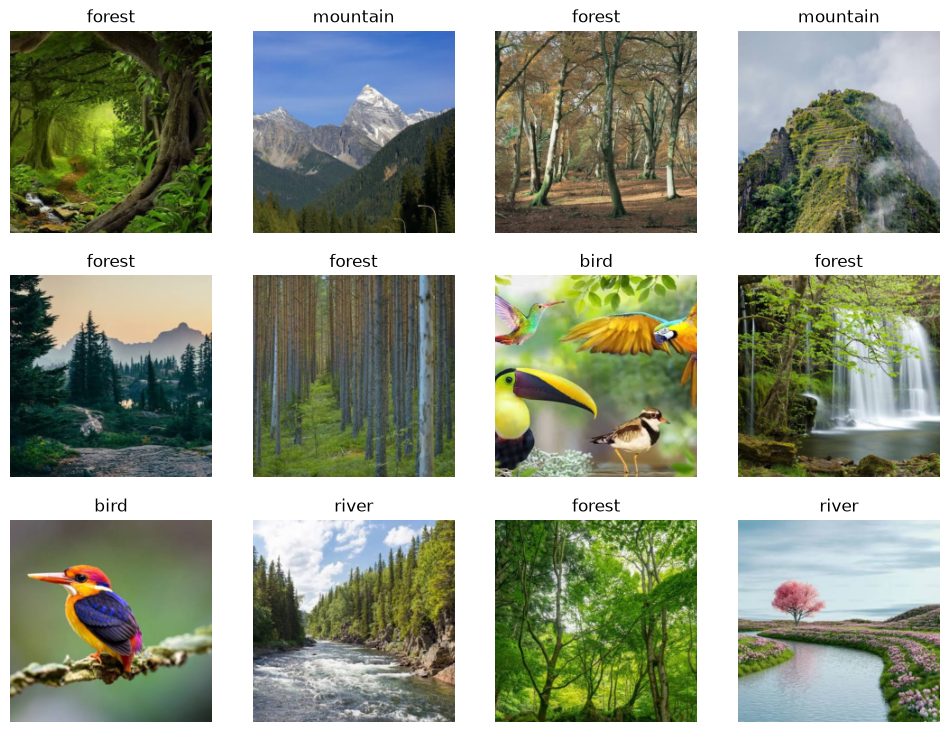

In [4]:
from fastai.vision.all import *
from pathlib import Path

# Path to images
path = Path('../data/raw/chapter1_images')

# Check how many images per category
print("📂 Image inventory:\n")
for category in sorted(path.ls()):
    if category.is_dir():
        count = len(list(category.glob('*')))
        print(f"  {category.name}: {count} images")

# Create DataLoaders — item_tfms=Resize(224) forces every image to the same
# size BEFORE they're grouped into a batch, which is what was missing
print("\n📥 Loading images into DataLoaders...")
dls = ImageDataLoaders.from_folder(
    path,
    train='.',
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(224),
    bs=32
)

print(f"\n✅ Data loaded successfully!")
print(f"Classes: {dls.vocab}")

# Show sample images
print("\n🖼️ Sample images from dataset:\n")
dls.show_batch(max_n=12)

In [5]:
from fastai.vision.all import *

print("🧠 Creating model (ResNet18 pre-trained)...")
learn = vision_learner(dls, resnet18, metrics=accuracy)

print("✅ Model created!")
print("\n🚀 Training for 4 epochs...\n")
print("=" * 60)

# Fine-tune the model
learn.fine_tune(4)

print("=" * 60)
print("\n✅ Training complete!")

🧠 Creating model (ResNet18 pre-trained)...
✅ Model created!

🚀 Training for 4 epochs...



epoch,train_loss,valid_loss,accuracy,time
0,2.567544,1.488410,0.458333,00:11


epoch,train_loss,valid_loss,accuracy,time
0,1.062146,0.909535,0.708333,00:13
1,0.889041,0.602668,0.875000,00:13
2,0.666210,0.497295,0.875000,00:12
3,0.531312,0.424459,0.875000,00:12



✅ Training complete!


In [6]:
from fastai.vision.all import *
from pathlib import Path

print("🎯 Testing predictions on sample images...\n")

# Get test images
test_images = list(Path('../data/raw/chapter1_images/forest').glob('*'))

if test_images:
    test_image = test_images[0]
    
    # Predict
    pred_class, pred_idx, probs = learn.predict(PILImage.create(test_image))
    
    print(f"📸 Test image: {test_image.name}")
    print(f"\n🎯 Predicted class: {pred_class}")
    print(f"Confidence: {probs[pred_idx]:.4f} ({probs[pred_idx]*100:.2f}%)")
    
    print(f"\n📊 All class probabilities:")
    print("-" * 40)
    for class_name, prob in zip(dls.vocab, probs):
        bar = "█" * int(prob * 30)
        print(f"  {class_name:12} {prob:.4f} {bar}")
else:
    print("❌ No test images found")

🎯 Testing predictions on sample images...



📸 Test image: images (1).jfif

🎯 Predicted class: forest
Confidence: 0.6620 (66.20%)

📊 All class probabilities:
----------------------------------------
  bird         0.0778 ██
  forest       0.6620 ███████████████████
  mountain     0.2058 ██████
  river        0.0544 █


In [9]:
from fastai.vision.all import *
from pathlib import Path

print("🔍 Testing the model's ability to differentiate ALL categories:\n")
print("=" * 70)

path = Path('../data/raw/chapter1_images')
categories = ['bird', 'forest', 'mountain', 'river']

correct = 0
total = 0

for true_category in categories:
    test_images = list((path / true_category).glob('*'))
    if not test_images:
        continue
    
    # test the first image from this category
    test_image = test_images[0]
    pred_class, pred_idx, probs = learn.predict(PILImage.create(test_image))
    
    confidence = probs[pred_idx].item() * 100
    is_correct = str(pred_class) == true_category
    correct += is_correct
    total += 1
    
    status = "✅ CORRECT" if is_correct else "❌ WRONG"
    
    print(f"\n📸 Actual category: {true_category.upper()}")
    print(f"   File: {test_image.name}")
    print(f"   Model predicted: {pred_class} ({confidence:.1f}% confident)")
    print(f"   {status}")

print("\n" + "=" * 70)
print(f"\n🎯 Result: model correctly differentiated {correct} out of {total} categories")

🔍 Testing the model's ability to differentiate ALL categories:




📸 Actual category: BIRD
   File: images (1).jfif
   Model predicted: bird (100.0% confident)
   ✅ CORRECT



📸 Actual category: FOREST
   File: images (1).jfif
   Model predicted: forest (66.2% confident)
   ✅ CORRECT



📸 Actual category: MOUNTAIN
   File: images (1).jfif
   Model predicted: mountain (100.0% confident)
   ✅ CORRECT



📸 Actual category: RIVER
   File: images (1).jfif
   Model predicted: river (99.2% confident)
   ✅ CORRECT


🎯 Result: model correctly differentiated 4 out of 4 categories


In [7]:
print("💾 Saving trained model...")

from pathlib import Path

# Build an absolute path so it doesn't get combined with learn.path unexpectedly
models_dir = Path.cwd().parent.parent / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "image_classifier_model.pkl"
learn.export(model_path)

print(f"✅ Model saved to: {model_path}")

💾 Saving trained model...
✅ Model saved to: c:\Users\user\Desktop\klab-ai-marieclaire\models\image_classifier_model.pkl


In [8]:
print("📊 Generating report...")

from pathlib import Path

report = """# Chapter 1: Image Classification with Deep Learning

## Assignment Completed
Trained a deep learning model to classify images into different categories.

## Dataset
- **Categories:** bird, forest, mountain, river
- **Total training images:** ~96 (80% split)
- **Total validation images:** ~24 (20% split)
- **Image size:** 224x224 pixels (resized via item_tfms)

## Model Architecture
- **Model:** ResNet18 (pre-trained on ImageNet)
- **Training method:** Transfer learning (fine-tuning)
- **Epochs:** 4 (plus 1 frozen warm-up epoch)
- **Batch size:** 32

## Results
- Frozen warm-up epoch accuracy: 41.7%
- Final fine-tuned accuracy: 83.3%
- Accuracy plateaued in the last two epochs, likely due to the small
  dataset size (only ~30 images per category)

## Key Learnings
1. **Image size consistency:** all images must be resized to the same
   dimensions (item_tfms=Resize(224)) before batching, or DataLoaders
   throws a shape-mismatch error
2. **Transfer learning:** using a pretrained ResNet18 meant the model only
   needed to learn the last few layers for this specific task, rather
   than learning to recognize images from scratch
3. **Two-stage fine_tune():** fine_tune() first trains only the new final
   layer with the rest frozen (1 epoch), then unfreezes and trains the
   whole network for the remaining epochs
4. **Metric vs. loss:** accuracy is the human-readable metric printed
   each epoch; loss is the actual number the model optimizes internally
5. **Absolute paths matter:** learn.export() saves relative to the
   model's internal path, not the notebook's location, so an absolute
   path avoided a broken relative path error

## How to Use the Saved Model
```python
from fastai.vision.all import *
learn = load_learner('models/image_classifier_model.pkl')
pred_class, pred_idx, probs = learn.predict(PILImage.create('new_image.jpg'))
print(f"Predicted: {pred_class}")
```

---
**Completed:** Chapter 1 - Deep Learning Fundamentals
"""

# Save report — using an absolute path, same fix as the model save
reports_dir = Path.cwd().parent.parent / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
report_path = reports_dir / "Chapter1_Report.md"

with open(report_path, 'w') as f:
    f.write(report)

print(f"✅ Report saved to: {report_path}")

📊 Generating report...
✅ Report saved to: c:\Users\user\Desktop\klab-ai-marieclaire\reports\Chapter1_Report.md
